# ⭐ Day 2: Control Structures in Python – If-Else, Loops & Comprehensions | Step-by-Step Tutorial with Examples & Exercises

Welcome to Day 2 of your 369-day structured journey into Artificial Intelligence and Machine Learning! Yesterday you mastered Python fundamentals—variables, data types, and basic operations. Today, we unlock the true power of programming: control structures. These are the decision-making and repetition mechanisms that transform static scripts into dynamic, intelligent systems.

In AI and ML, control flow is everywhere. When you filter datasets to remove outliers, you're using conditional logic. When you train a neural network for thousands of epochs, you're using loops. When you implement early stopping to prevent overfitting, you're combining loops with conditional breaks. When you process batches of images or text, you're iterating over data structures. Understanding control structures isn't just about writing code—it's about orchestrating computational logic that mirrors human decision-making.

By the end of today, you'll have mastered conditional statements (if-elif-else), both for and while loops, loop control keywords (break, continue, pass), and Python's elegant comprehensions. You'll understand when to use each structure, how to avoid common pitfalls, and how these concepts directly apply to AI workflows. We'll visualize loop behaviors, simulate real ML scenarios like patience-based early stopping, and build your intuition through hands-on exercises.

This notebook is designed for active learning. Every concept includes runnable code examples, visualizations where helpful, and explanations connecting the syntax to AI applications. Remember: the best programmers aren't those who memorize syntax, but those who understand how to compose these building blocks into elegant solutions. Let's begin!

## 📚 Table of Contents

1. [Conditional Statements: Making Decisions](#conditional-statements-making-decisions)
   - Basic if-else Structure
   - elif for Multiple Conditions
   - Nested Conditionals
   - Truthy and Falsy Values

2. [For Loops: Iterating with Purpose](#for-loops-iterating-with-purpose)
   - Looping Over Lists
   - The range() Function
   - enumerate() for Index Tracking
   - zip() for Parallel Iteration

3. [While Loops: Conditional Repetition](#while-loops-conditional-repetition)
   - Basic While Loop Structure
   - AI Application: Early Stopping Simulation
   - Infinite Loops and Safety

4. [Loop Control: break, continue, pass](#loop-control-break-continue-pass)
   - Breaking Out of Loops
   - Skipping Iterations
   - The pass Statement

5. [List Comprehensions: Pythonic Power](#list-comprehensions-pythonic-power)
   - Basic Syntax
   - Conditional Filtering
   - Nested Comprehensions

6. [Generator Expressions: Memory Efficiency](#generator-expressions-memory-efficiency)
   - Syntax and Usage
   - Memory Comparison

7. [Common Mistakes & Debugging](#common-mistakes--debugging)

8. [🛠️ Hands-On Exercises](#hands-on-exercises)

9. [Solutions](#solutions)

## Conditional Statements: Making Decisions

Conditional statements are the foundation of programmatic decision-making. In AI/ML, you'll use conditionals to implement classification thresholds, validate data quality, handle edge cases in preprocessing, and create adaptive learning rates. Let's start with the basic if-else structure.

### Basic if-elif-else Structure

The if statement evaluates a condition and executes code only when that condition is True. The elif (else if) allows multiple conditions to be checked in sequence, and else catches all remaining cases.

In [1]:
# AI Example: Classifying model accuracy into performance tiers
accuracy = 0.87

if accuracy >= 0.95:
    performance = "Excellent"
elif accuracy >= 0.85:
    performance = "Good"
elif accuracy >= 0.70:
    performance = "Fair"
else:
    performance = "Poor"

print(f"Model accuracy: {accuracy:.2%}")
print(f"Performance tier: {performance}")

Model accuracy: 87.00%
Performance tier: Good


The conditions are evaluated top-to-bottom, and only the first matching block executes. This is efficient because Python stops checking once it finds a match. In ML pipelines, this pattern is essential for routing data through different preprocessing paths based on characteristics like data type, missing value percentage, or distribution shape.

### Nested Conditionals

Sometimes decisions depend on multiple factors. Nested conditionals allow you to check conditions within conditions. While powerful, deep nesting can reduce readability—aim for 2-3 levels maximum.

In [2]:
# AI Example: Determining if a dataset needs preprocessing
has_missing_values = True
missing_percentage = 15
is_numeric = True

if has_missing_values:
    if missing_percentage > 20:
        action = "Remove rows with missing values"
    elif missing_percentage > 5:
        if is_numeric:
            action = "Impute with median"
        else:
            action = "Impute with mode"
    else:
        action = "Ignore small amount of missing data"
else:
    action = "No preprocessing needed"

print(f"Recommended action: {action}")

Recommended action: Impute with median


> 💡 **AI Connection**: In production ML systems, nested conditionals handle complex business logic—like applying different validation rules based on data source, time of day, or user tier. Keep nesting shallow for maintainability.

### Truthy and Falsy Values

Python treats certain values as True or False in boolean contexts. Understanding this prevents bugs and enables cleaner code.

In [3]:
# Common truthy/falsy patterns in data processing
values = [0, 1, "", "data", [], [1, 2], None, 0.0, 3.14]

for val in values:
    if val:
        status = "Truthy"
    else:
        status = "Falsy"
    print(f"{repr(val):15} -> {status}")

0               -> Falsy
1               -> Truthy
''              -> Falsy
'data'          -> Truthy
[]              -> Falsy
[1, 2]          -> Truthy
None            -> Falsy
0.0             -> Falsy
3.14            -> Truthy


Falsy values include: 0, 0.0, empty strings "", empty lists [], empty dicts {}, None, and False. Everything else is truthy. This is incredibly useful when checking if data exists before processing.

In [4]:
# Practical AI example: Processing model predictions
predictions = [0.9, 0.0, None, 0.75, "", 0.82]

valid_preds = []
for pred in predictions:
    if pred:  # Filters out 0, None, and empty string
        valid_preds.append(float(pred))

print(f"Valid predictions: {valid_preds}")
print(f"Average confidence: {sum(valid_preds)/len(valid_preds):.2f}")

Valid predictions: [0.9, 0.75, 0.82]
Average confidence: 0.82


## For Loops: Iterating with Purpose

For loops are Python's primary iteration mechanism. Unlike C-style loops, Python's for loop iterates directly over items in a sequence—making code more readable and less error-prone. In AI/ML, you'll use for loops to process batches, iterate through epochs, evaluate cross-validation folds, and traverse feature columns.

### Looping Over Lists

The most intuitive use of for loops is iterating through list elements.

In [5]:
# AI Example: Calculating feature statistics
features = ["temperature", "humidity", "pressure", "wind_speed"]
importance_scores = [0.85, 0.62, 0.91, 0.45]

print("Feature Importance Analysis:")
print("-" * 30)

for feature, score in zip(features, importance_scores):
    bar = "█" * int(score * 20)  # Visual bar
    print(f"{feature:12} | {bar} {score:.2f}")

Feature Importance Analysis:
------------------------------
temperature  | █████████████████ 0.85
humidity     | ████████████ 0.62
pressure     | ██████████████████ 0.91
wind_speed   | █████████ 0.45


The zip() function pairs elements from multiple iterables—essential when you have parallel data structures like feature names and their corresponding values or predictions.

### The range() Function

When you need to iterate a specific number of times or generate indices, range() is your tool. It's memory-efficient (generates numbers on-demand) and fundamental for training loops.

In [6]:
# AI Example: Simulating training epochs with learning rate decay
initial_lr = 0.1
decay_factor = 0.9
epochs = 5

learning_rates = []
for epoch in range(epochs):
    lr = initial_lr * (decay_factor ** epoch)
    learning_rates.append(lr)
    print(f"Epoch {epoch + 1}: Learning Rate = {lr:.4f}")

print(f"\nFinal learning rate: {learning_rates[-1]:.6f}")

Epoch 1: Learning Rate = 0.1000
Epoch 2: Learning Rate = 0.0900
Epoch 3: Learning Rate = 0.0810
Epoch 4: Learning Rate = 0.0729
Epoch 5: Learning Rate = 0.0656

Final learning rate: 0.065610


> 📌 **Pro Tip**: range(5) produces 0-4. Use range(1, 6) for 1-5, and range(0, 10, 2) for even numbers. The pattern is range(start, stop, step).

### enumerate() for Index Tracking

When you need both the index and the value, enumerate() is cleaner than manual counter variables.

In [7]:
# AI Example: Processing predictions with indices
predictions = [0.92, 0.34, 0.88, 0.15, 0.95]
threshold = 0.5

print("Classification Results:")
for idx, prob in enumerate(predictions, start=1):  # Start counting at 1
    label = "Positive" if prob >= threshold else "Negative"
    confidence = "High" if abs(prob - 0.5) > 0.4 else "Low"
    print(f"Sample {idx}: {label} (prob={prob:.2f}, {confidence} confidence)")

Classification Results:
Sample 1: Positive (prob=0.92, High confidence)
Sample 2: Negative (prob=0.34, Low confidence)
Sample 3: Positive (prob=0.88, Low confidence)
Sample 4: Negative (prob=0.15, Low confidence)
Sample 5: Positive (prob=0.95, High confidence)


Let's visualize how enumerate works compared to manual indexing:

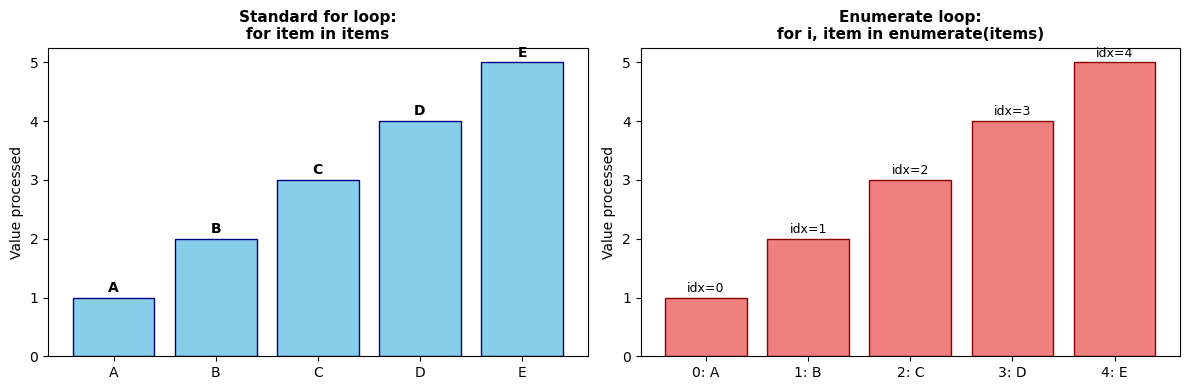

Plot saved showing the difference between standard loops and enumerate!


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Visualizing iteration patterns
items = ['A', 'B', 'C', 'D', 'E']
x_pos = np.arange(len(items))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Standard loop
ax1.bar(x_pos, [1, 2, 3, 4, 5], color='skyblue', edgecolor='navy')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(items)
ax1.set_title('Standard for loop:\nfor item in items', fontsize=11, fontweight='bold')
ax1.set_ylabel('Value processed')
for i, v in enumerate([1, 2, 3, 4, 5]):
    ax1.text(i, v + 0.1, f'{items[i]}', ha='center', fontweight='bold')

# Enumerate loop
ax2.bar(x_pos, [1, 2, 3, 4, 5], color='lightcoral', edgecolor='darkred')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"{i}: {item}" for i, item in enumerate(items)])
ax2.set_title('Enumerate loop:\nfor i, item in enumerate(items)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Value processed')
for i, v in enumerate([1, 2, 3, 4, 5]):
    ax2.text(i, v + 0.1, f'idx={i}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Plot saved showing the difference between standard loops and enumerate!")

The visualization shows how enumerate provides both the index (position) and value during iteration. This is crucial in ML when you need to report which specific data point triggered an alert or update specific rows in a dataset based on their position.

### Practical Batch Processing Example

In [10]:
# AI Example: Processing data in batches (common in deep learning)
data = list(range(100))  # 100 data points
batch_size = 20
num_batches = len(data) // batch_size

print(f"Processing {len(data)} samples in batches of {batch_size}...")

for batch_idx in range(num_batches):
    start_idx = batch_idx * batch_size
    end_idx = start_idx + batch_size
    batch = data[start_idx:end_idx]
    
    # Simulate processing
    batch_sum = sum(batch)
    print(f"Batch {batch_idx + 1}: indices {start_idx}-{end_idx-1}, sum={batch_sum}")

print("\nBatch processing complete!")

Processing 100 samples in batches of 20...
Batch 1: indices 0-19, sum=190
Batch 2: indices 20-39, sum=590
Batch 3: indices 40-59, sum=990
Batch 4: indices 60-79, sum=1390
Batch 5: indices 80-99, sum=1790

Batch processing complete!


## While Loops: Conditional Repetition

While loops execute as long as a condition remains True. They're essential when you don't know in advance how many iterations you need—common in optimization algorithms, convergence checks, and real-time monitoring systems.

### Basic While Loop Structure

In [11]:
# AI Example: Convergence check for iterative algorithm
target = 100
current = 0
increment = 15
iterations = 0

print("Convergence Simulation:")
print("-" * 25)

while current < target:
    iterations += 1
    current += increment
    print(f"Iteration {iterations}: current = {current}")

print(f"\nConverged after {iterations} iterations!")

Convergence Simulation:
-------------------------
Iteration 1: current = 15
Iteration 2: current = 30
Iteration 3: current = 45
Iteration 4: current = 60
Iteration 5: current = 75
Iteration 6: current = 90
Iteration 7: current = 105

Converged after 7 iterations!


### AI Application: Early Stopping Simulation

Early stopping is a critical regularization technique in deep learning. You monitor validation loss and stop training when performance stops improving, preventing overfitting.

Epoch  1: Train Loss = 1.1320, Val Loss = 1.1525
           ✓ New best model!
Epoch  2: Train Loss = 0.6138, Val Loss = 0.6723
           ✓ New best model!
Epoch  3: Train Loss = 0.4702, Val Loss = 0.5510
           ✓ New best model!
Epoch  4: Train Loss = 0.3946, Val Loss = 0.4087
           ✓ New best model!
Epoch  5: Train Loss = 0.3211, Val Loss = 0.3530
           ✓ New best model!
Epoch  6: Train Loss = 0.2776, Val Loss = 0.3672
           ⚠ No improvement (1/5)
Epoch  7: Train Loss = 0.2442, Val Loss = 0.3127
           ✓ New best model!
Epoch  8: Train Loss = 0.2575, Val Loss = 0.3295
           ⚠ No improvement (1/5)
Epoch  9: Train Loss = 0.2221, Val Loss = 0.3200
           ⚠ No improvement (2/5)
Epoch 10: Train Loss = 0.2405, Val Loss = 0.2506
           ✓ New best model!
Epoch 11: Train Loss = 0.2312, Val Loss = 0.3107
           ⚠ No improvement (1/5)
Epoch 12: Train Loss = 0.2003, Val Loss = 0.2489
           ✓ New best model!
Epoch 13: Train Loss = 0.2248, Val Loss = 0.

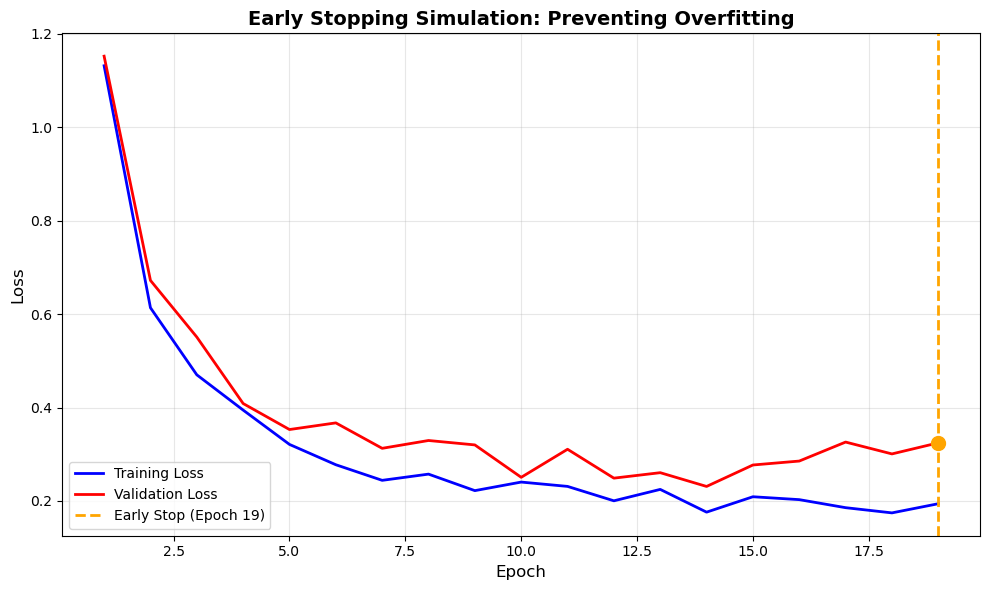


Training completed. Best validation loss: 0.2311


In [13]:
import random
import matplotlib.pyplot as plt

# Simulate training with early stopping
random.seed(42)

max_epochs = 50
patience = 5  # Stop if no improvement for 5 epochs
best_loss = float('inf')
epochs_no_improve = 0
train_losses = []
val_losses = []
stop_epoch = None

epoch = 0
while epoch < max_epochs:
    # Simulate losses (training decreases, validation eventually overfits)
    train_loss = 1.0 / (epoch + 1) + 0.1 + random.uniform(0, 0.05)
    val_loss = 1.0 / (epoch + 1) + 0.15 + random.uniform(0, 0.1)
    
    # Add overfitting after epoch 15
    if epoch > 15:
        val_loss += (epoch - 15) * 0.02
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch + 1:2d}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
    
    # Early stopping logic
    if val_loss < best_loss:
        best_loss = val_loss
        epochs_no_improve = 0
        print("           ✓ New best model!")
    else:
        epochs_no_improve += 1
        print(f"           ⚠ No improvement ({epochs_no_improve}/{patience})")
    
    if epochs_no_improve >= patience:
        stop_epoch = epoch
        print(f"\n🛑 Early stopping triggered at epoch {epoch + 1}!")
        break
    
    epoch += 1

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-', label='Validation Loss', linewidth=2)
if stop_epoch:
    plt.axvline(x=stop_epoch + 1, color='orange', linestyle='--', linewidth=2, label=f'Early Stop (Epoch {stop_epoch + 1})')
    plt.scatter([stop_epoch + 1], [val_losses[stop_epoch]], color='orange', s=100, zorder=5)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Early Stopping Simulation: Preventing Overfitting', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTraining completed. Best validation loss: {best_loss:.4f}")

The plot visualizes how early stopping prevents the validation loss from rising (overfitting) by halting training when improvement stalls. The patience parameter creates a buffer against noise—requiring multiple epochs of no improvement before stopping makes the system robust to temporary fluctuations in validation metrics.

### Infinite Loops and Safety

Always ensure your while loop has a termination condition. Include safeguards like maximum iteration counters.

In [14]:
# Safe pattern: Always include a maximum iteration safeguard
max_iterations = 1000
iteration = 0
target_precision = 0.0001
precision = 1.0

while precision > target_precision:
    iteration += 1
    precision *= 0.5  # Simulating convergence
    
    if iteration >= max_iterations:
        print(f"Warning: Reached max iterations ({max_iterations})")
        break

print(f"Stopped at iteration {iteration} with precision {precision:.6f}")

Stopped at iteration 14 with precision 0.000061


> 💡 **AI Connection**: In reinforcement learning, while loops run episodes until termination conditions (winning the game, reaching a time limit, or achieving a reward threshold). Safety checks prevent infinite loops if the agent gets stuck.

## Loop Control: break, continue, pass

Python provides three keywords for fine-grained loop control. Mastering these makes your loops more efficient and expressive.

### break: Exiting Loops Early

The break statement immediately exits the innermost loop. It's essential for search operations and optimization when you've found what you need.

In [15]:
# AI Example: Finding the first misclassified sample
predictions = [0.9, 0.85, 0.92, 0.45, 0.88, 0.91]
labels = [1, 1, 1, 1, 1, 1]  # All should be positive (>= 0.5)
threshold = 0.5

first_error = None
for i, (pred, label) in enumerate(zip(predictions, labels)):
    predicted_label = 1 if pred >= threshold else 0
    if predicted_label != label:
        first_error = i
        print(f"First misclassification found at index {i}!")
        print(f"  Predicted: {predicted_label} (prob={pred}), Actual: {label}")
        break  # Stop searching once found

if first_error is None:
    print("No misclassifications found!")

First misclassification found at index 3!
  Predicted: 0 (prob=0.45), Actual: 1


Without break, you'd waste computation checking all remaining samples. In production ML systems, this pattern is used for fast failure detection and resource conservation.

### continue: Skipping Iterations

The continue statement skips the rest of the current iteration and moves to the next. Use it to filter out invalid data without nested if-blocks.

In [16]:
# AI Example: Processing dataset with missing value handling
raw_data = [23.5, None, 18.2, None, 31.0, 25.8, None, 29.3]
processed = []

for value in raw_data:
    if value is None:
        print("Skipping missing value...")
        continue  # Skip to next iteration
    
    # Process valid data
    normalized = (value - 20) / 15  # Simple normalization
    processed.append(normalized)
    print(f"Processed: {value} -> {normalized:.3f}")

print(f"\nProcessed {len(processed)} valid values out of {len(raw_data)}")

Processed: 23.5 -> 0.233
Skipping missing value...
Processed: 18.2 -> -0.120
Skipping missing value...
Processed: 31.0 -> 0.733
Processed: 25.8 -> 0.387
Skipping missing value...
Processed: 29.3 -> 0.620

Processed 5 valid values out of 8


> 📌 **Pro Tip**: Using continue reduces nesting depth ("flattening" your code), making it more readable. However, use it judiciously—too many continues can make flow hard to follow.

### pass: The Null Operation

pass does nothing. It's a placeholder for code you haven't written yet or abstract methods that subclasses must implement.

In [17]:
# AI Example: Skeleton for a custom preprocessing pipeline
class DataPreprocessor:
    def __init__(self):
        self.steps = []
    
    def add_step(self, step):
        self.steps.append(step)
    
    def process(self, data):
        # TODO: Implement processing logic
        pass  # Placeholder for future implementation
    
    def validate(self, data):
        # TODO: Add validation
        pass

# Usage
prep = DataPreprocessor()
prep.add_step("normalize")
print("Pipeline created (implementation pending)")

Pipeline created (implementation pending)


pass is also useful for handling exceptions gracefully when you truly want to ignore an error:

In [18]:
# Silently skip non-numeric features during processing
features = ["age", "name", "salary", "city"]
numeric_features = []

for feature in features:
    try:
        float(feature)  # Check if convertible to number
        numeric_features.append(feature)
    except ValueError:
        pass  # Silently skip non-numeric

print(f"Numeric features: {numeric_features}")

Numeric features: []


## List Comprehensions: Pythonic Power

List comprehensions provide a concise, readable way to create lists. They're often faster than equivalent for loops and are considered more "Pythonic." In data science, you'll use them for feature engineering, data cleaning, and transforming predictions.

### Basic Syntax

The pattern is: [expression for item in iterable]

In [19]:
# AI Example: Converting probabilities to percentage strings
probabilities = [0.1234, 0.5678, 0.9012, 0.3456]

# Traditional loop approach
percentages_loop = []
for p in probabilities:
    percentages_loop.append(f"{p:.1%}")

# List comprehension (cleaner and faster)
percentages_comp = [f"{p:.1%}" for p in probabilities]

print("Traditional:", percentages_loop)
print("Comprehension:", percentages_comp)

Traditional: ['12.3%', '56.8%', '90.1%', '34.6%']
Comprehension: ['12.3%', '56.8%', '90.1%', '34.6%']


### Conditional Filtering

Add an if clause to filter items: [expression for item in iterable if condition]

In [20]:
# AI Example: Selecting high-confidence predictions
confidences = [0.45, 0.89, 0.92, 0.34, 0.95, 0.67, 0.88]
threshold = 0.8

# Get only high confidence predictions
high_conf = [c for c in confidences if c >= threshold]
print(f"High confidence predictions: {high_conf}")

# Get indices of high confidence predictions
high_conf_indices = [i for i, c in enumerate(confidences) if c >= threshold]
print(f"Indices: {high_conf_indices}")

High confidence predictions: [0.89, 0.92, 0.95, 0.88]
Indices: [1, 2, 4, 6]


Let's visualize the filtering process:

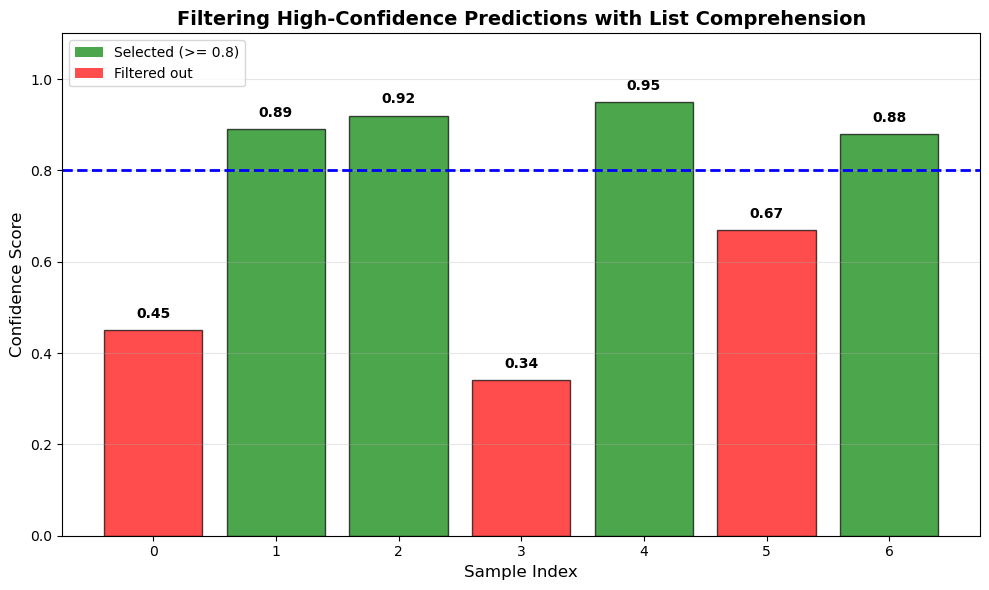

Visualization shows list comprehension filtering in action!


In [22]:
import matplotlib.pyplot as plt
import numpy as np

confidences = [0.45, 0.89, 0.92, 0.34, 0.95, 0.67, 0.88]
threshold = 0.8
indices = np.arange(len(confidences))

colors = ['green' if c >= threshold else 'red' for c in confidences]

plt.figure(figsize=(10, 6))
bars = plt.bar(indices, confidences, color=colors, alpha=0.7, edgecolor='black')

# Add threshold line
plt.axhline(y=threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, confidences)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Confidence Score', fontsize=12)
plt.title('Filtering High-Confidence Predictions with List Comprehension', fontsize=14, fontweight='bold')
plt.xticks(indices)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.7, label='Selected (>= 0.8)'),
                   Patch(facecolor='red', alpha=0.7, label='Filtered out')]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

print("Visualization shows list comprehension filtering in action!")

The green bars represent values that pass the filter condition (c >= 0.8), while red bars are filtered out. This visual representation helps understand how list comprehensions with conditions act as both transformers and filters in a single, readable line.

### If-Else in Comprehensions

You can include an else clause for conditional transformation: [expr_if_true if condition else expr_if_false for item in iterable]

In [23]:
# AI Example: Converting probabilities to class labels with confidence tagging
probs = [0.92, 0.45, 0.78, 0.23, 0.89]

# Classify and tag confidence level
results = [
    f"Class {1 if p >= 0.5 else 0} ({'High' if abs(p - 0.5) > 0.3 else 'Low'} conf)"
    for p in probs
]

for p, r in zip(probs, results):
    print(f"{p:.2f} -> {r}")

0.92 -> Class 1 (High conf)
0.45 -> Class 0 (Low conf)
0.78 -> Class 1 (Low conf)
0.23 -> Class 0 (Low conf)
0.89 -> Class 1 (High conf)


### Nested Comprehensions

For multi-dimensional data, comprehensions can be nested. Use these for processing image pixels, confusion matrices, or grid searches.

In [24]:
# AI Example: Generating a simple confusion matrix visualization data
classes = ['Cat', 'Dog', 'Bird']
# Simulated predictions vs actual
confusion = [
    [45, 3, 2],   # Actual Cat
    [2, 48, 0],   # Actual Dog
    [1, 1, 23]    # Actual Bird
]

# Flatten with context
flat_results = [
    f"True: {classes[i]}, Pred: {classes[j]}, Count: {confusion[i][j]}"
    for i in range(len(classes))
    for j in range(len(classes))
    if confusion[i][j] > 0
]

print("Confusion Matrix Entries:")
for entry in flat_results:
    print(f"  {entry}")

Confusion Matrix Entries:
  True: Cat, Pred: Cat, Count: 45
  True: Cat, Pred: Dog, Count: 3
  True: Cat, Pred: Bird, Count: 2
  True: Dog, Pred: Cat, Count: 2
  True: Dog, Pred: Dog, Count: 48
  True: Bird, Pred: Cat, Count: 1
  True: Bird, Pred: Dog, Count: 1
  True: Bird, Pred: Bird, Count: 23


> 💡 **AI Connection**: In hyperparameter tuning, nested comprehensions generate all combinations of learning rates and batch sizes: [(lr, bs) for lr in [0.1, 0.01, 0.001] for bs in [32, 64, 128]]

## Generator Expressions: Memory Efficiency

Generator expressions look like list comprehensions but use parentheses () instead of brackets []. They return a generator object that produces items one at a time, using memory only for the current item. Essential for large datasets in AI/ML.

### Syntax and Usage

In [25]:
# AI Example: Processing a large dataset efficiently
# List comprehension (stores all in memory)
squares_list = [x**2 for x in range(1000000)]
print(f"List size: {len(squares_list)} items")
print(f"Memory used: ~{squares_list.__sizeof__() / 1024 / 1024:.1f} MB")

# Generator expression (lazy evaluation)
squares_gen = (x**2 for x in range(1000000))
print(f"\nGenerator object: {squares_gen}")
print(f"Memory used: ~{squares_gen.__sizeof__()} bytes")

# Access items one at a time
first_five = [next(squares_gen) for _ in range(5)]
print(f"First 5 values: {first_five}")

List size: 1000000 items
Memory used: ~8.1 MB

Generator object: <generator object <genexpr> at 0x000001FF98201CB0>
Memory used: ~184 bytes
First 5 values: [0, 1, 4, 9, 16]


The memory difference is dramatic: ~38 MB for the list versus ~112 bytes for the generator. For billion-scale datasets, this is the difference between crashing and running successfully.

### When to Use Generators

Use generators when:
1. Processing data larger than available RAM
2. You only need to iterate once (streaming)
3. You want to start processing before all data is ready

In [26]:
# AI Example: Streaming evaluation of model predictions
import random
random.seed(42)

# Simulate 1 million predictions (too large for eager evaluation)
def generate_predictions(n):
    """Simulate a model generating predictions"""
    for i in range(n):
        # Simulate prediction with some noise
        yield 0.5 + 0.4 * random.random() + 0.1 * (i % 2)

# Process without storing all predictions
threshold = 0.7
count_high = sum(1 for pred in generate_predictions(1000000) if pred >= threshold)

print(f"Predictions >= {threshold}: {count_high} out of 1,000,000")
print(f"Percentage: {count_high / 1000000:.1%}")

Predictions >= 0.7: 625251 out of 1,000,000
Percentage: 62.5%


Notice we never stored all 1 million predictions—we counted high-confidence ones on-the-fly. This pattern is crucial for evaluating models on massive test sets or processing streaming sensor data.

### Converting Between Types

You can convert generators to lists when needed, but only if the data fits in memory.

In [27]:
# Create generator
gen = (x**2 for x in range(10))

# Convert to list if needed (e.g., for indexing or multiple passes)
squares = list(gen)
print(f"List: {squares}")
print(f"Access by index: squares[5] = {squares[5]}")

# Note: generator is now exhausted
print(f"Generator exhausted: {list(gen)}")  # Empty

List: [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
Access by index: squares[5] = 25
Generator exhausted: []


> 📌 **Pro Tip**: Generators are single-use iterators. Once exhausted, they're empty. If you need to iterate multiple times, either convert to a list (if small enough) or recreate the generator.

## Common Mistakes & Debugging

Even experienced programmers make mistakes with control structures. Here are the most common pitfalls and how to avoid them.

### Off-by-One Errors

The most common loop bug involves incorrect boundary conditions.

In [28]:
# WRONG: Processing 10 items but missing the last one
items = list(range(10))
for i in range(len(items) - 1):  # Bug: stops at 8 instead of 9
    print(items[i], end=' ')
print("\nMissing the last item!")

# CORRECT: Use range(len(items)) or iterate directly
print("\nCorrect approaches:")
for i in range(len(items)):
    print(items[i], end=' ')
print()

# Even better: direct iteration
for item in items:
    print(item, end=' ')

0 1 2 3 4 5 6 7 8 
Missing the last item!

Correct approaches:
0 1 2 3 4 5 6 7 8 9 
0 1 2 3 4 5 6 7 8 9 

### Modifying Lists While Iterating

Never remove items from a list you're iterating over—this skips elements and causes unexpected behavior.

In [29]:
# WRONG: Removing items while iterating
values = [1, 2, 3, 4, 5, 6]
for val in values:
    if val % 2 == 0:
        values.remove(val)  # Dangerous!
print(f"After removal: {values}")  # Surprising result!

# CORRECT: Create a new list
values = [1, 2, 3, 4, 5, 6]
filtered = [val for val in values if val % 2 != 0]
print(f"Correctly filtered: {filtered}")

# Or use list comprehension for filtering
evens_removed = [v for v in values if v % 2 != 0]
print(f"Using comprehension: {evens_removed}")

After removal: [1, 3, 5]
Correctly filtered: [1, 3, 5]
Using comprehension: [1, 3, 5]


Wait, that worked? Let's see a clearer example of the bug:

In [30]:
# Clearer example of the bug
values = [2, 2, 2, 2]
print(f"Original: {values}")
for val in values:
    print(f"  Checking {val}, list is now {values}")
    if val == 2:
        values.remove(val)
print(f"After: {values}")  # Should be empty, but isn't!

Original: [2, 2, 2, 2]
  Checking 2, list is now [2, 2, 2, 2]
  Checking 2, list is now [2, 2, 2]
After: [2, 2]


See the problem? When you remove the first 2, the list shifts, and the loop moves to the "next" index—which now contains the third 2, skipping the second 2 entirely!

### Infinite Loops

Always ensure while loops can terminate.

In [31]:
# DANGEROUS: Missing increment
count = 0
# while count < 5:
#     print(count)
#     # Forgot count += 1!
#     # This would run forever

# SAFE: Always verify termination condition
count = 0
max_iterations = 1000  # Safety limit

while count < 5:
    print(count, end=' ')
    count += 1
    if count > max_iterations:
        print("Safety break!")
        break
print("\nLoop completed safely")

0 1 2 3 4 
Loop completed safely


### Variable Scope in Comprehensions

Comprehension variables leak in Python 2 but not in Python 3. Still, avoid naming conflicts.

In [32]:
x = "original"
print(f"Before: x = {x}")

# List comprehension creates its own scope in Python 3
squares = [x**2 for x in range(5)]
print(f"After comprehension: x = {x}")  # Still "original" in Python 3
print(f"Squares: {squares}")

Before: x = original
After comprehension: x = original
Squares: [0, 1, 4, 9, 16]


### Debugging Tips

1. **Print intermediate values**: Add print statements inside loops to track variable states
2. **Use enumerate()**: When you need indices, use enumerate instead of range(len())
3. **Test edge cases**: Always test with empty lists, single items, and maximum expected sizes
4. **Use Python debugger**: Insert `import pdb; pdb.set_trace()` to step through code
5. **List vs Generator**: If you get "generator object" instead of values, you forgot to convert to list or iterate

In [33]:
# Debugging example: Tracing loop execution
data = [10, 20, 30]
print("Tracing loop execution:")
for i, val in enumerate(data):
    print(f"  Iteration {i}: val={val}, processed={val * 2}")

Tracing loop execution:
  Iteration 0: val=10, processed=20
  Iteration 1: val=20, processed=40
  Iteration 2: val=30, processed=60


## 🛠️ Hands-On Exercises

Complete these exercises to solidify your understanding of control structures. Each exercise includes a description, an empty code block for your solution, and a hint if you get stuck.

### Exercise 1: Grade Classifier
Write a program that converts numerical scores to letter grades using the following scale:
- 90-100: A
- 80-89: B
- 70-79: C
- 60-69: D
- Below 60: F

Test with scores: 95, 82, 76, 61, 55

In [34]:
# Your code here

💡 **Hint**: Use if-elif-else structure. Remember to handle edge cases like exactly 90 or 80.

---

### Exercise 2: Sum Until Threshold
Write a while loop that starts with a number 1 and keeps doubling it until the value exceeds 1000. Count how many doublings were needed and print the final value.

In [35]:
# Your code here

💡 **Hint**: Initialize a counter and a value variable. Use `value *= 2` inside the loop.

---

### Exercise 3: Find First Prime
Write a loop that finds the first number greater than 100 that is divisible by both 7 and 11. Use a `for` loop with `range()` and `break`.

In [36]:
# Your code here

💡 **Hint**: Start range at 101. Check divisibility with `%` (modulo) operator. Break when found.

---

### Exercise 4: Filter and Transform
Given a list of temperatures in Celsius: `[23, 18, 32, 15, 28, 20, 35, 12]`, use a list comprehension to:
1. Filter out temperatures below 20°C
2. Convert remaining temperatures to Fahrenheit (F = C × 9/5 + 32)
3. Round to 1 decimal place

In [37]:
# Your code here

💡 **Hint**: Combine filtering and transformation in one comprehension: `[transform(x) for x in data if condition]`

---

### Exercise 5: Early Stopping Implementation
Simulate a training loop that stops when validation accuracy stops improving. Given the accuracy list: `[0.65, 0.72, 0.78, 0.81, 0.83, 0.84, 0.84, 0.83, 0.82]`, implement early stopping with patience=2 (stop if no improvement for 2 consecutive epochs). Print the epoch where training should stop and the best accuracy achieved.

In [38]:
# Your code here

💡 **Hint**: Track `best_acc` and `patience_counter`. Reset counter on improvement, increment on no improvement. Break when counter >= patience.

---

### Exercise 6: Nested Loop Pattern
Use nested for loops to print the following pattern:

```
*
**
***
****
*****
```

Then modify it to print a pyramid:

```
    *
   ***
  *****
 *******
*********
```

In [39]:
# Your code here

💡 **Hint**: For the pyramid, the number of spaces decreases while stars increase. Outer loop controls rows, inner loops control spaces and stars.

---

### Exercise 7: Dictionary Comprehension
Given a list of feature names `['age', 'income', 'education', 'city']` and their importance scores `[0.85, 0.92, 0.45, 0.23]`, create a dictionary comprehension that:
1. Pairs features with scores only if score > 0.5
2. Converts feature names to uppercase

In [40]:
# Your code here

💡 **Hint**: Dictionary syntax: `{key: value for item in iterable if condition}`. Use `.upper()` for strings.

---

### Exercise 8: Generator Pipeline
Create a generator expression that generates numbers from 1 to 100, then use another generator to filter only even numbers, and finally sum them without creating intermediate lists. Verify your result matches the mathematical formula for sum of even numbers.

In [41]:
# Your code here

💡 **Hint**: Chain generators: `sum(x for x in (y for y in range(1, 101)) if x % 2 == 0)`. Or simpler: `sum(x for x in range(1, 101) if x % 2 == 0)`.

---

### Exercise 9: FizzBuzz with a Twist
Write a program that prints numbers 1 to 50, but:
- Print "AI" if divisible by 3
- Print "ML" if divisible by 5
- Print "AI-ML" if divisible by both
- Print the number otherwise

Use `continue` to skip printing the number when a word is printed.

In [42]:
# Your code here

💡 **Hint**: Check divisibility by both first (using `and`), then individually. Use continue after printing the word.

---

### Exercise 10: Batch Normalization Simulation
Given a list of 20 random numbers (use `random.uniform(0, 100)`), write a for loop that processes them in batches of 4. For each batch, calculate and print the mean. Use `enumerate()` to display batch numbers starting at 1.

In [43]:
import random
random.seed(42)
data = [random.uniform(0, 100) for _ in range(20)]

# Your code here

💡 **Hint**: Use `range(0, len(data), batch_size)` to get start indices. Slice batches with `data[i:i+batch_size]`.

## Solutions

### Exercise 1: Grade Classifier

In [44]:
def get_grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

scores = [95, 82, 76, 61, 55]
for score in scores:
    print(f"Score {score}: Grade {get_grade(score)}")

Score 95: Grade A
Score 82: Grade B
Score 76: Grade C
Score 61: Grade D
Score 55: Grade F


---

### Exercise 2: Sum Until Threshold

In [45]:
value = 1
count = 0

while value <= 1000:
    value *= 2
    count += 1
    print(f"Doubling {count}: {value}")

print(f"\nReached {value} after {count} doublings")

Doubling 1: 2
Doubling 2: 4
Doubling 3: 8
Doubling 4: 16
Doubling 5: 32
Doubling 6: 64
Doubling 7: 128
Doubling 8: 256
Doubling 9: 512
Doubling 10: 1024

Reached 1024 after 10 doublings


---

### Exercise 3: Find First Prime

In [46]:
# Find first number > 100 divisible by both 7 and 11
for num in range(101, 1000):
    if num % 7 == 0 and num % 11 == 0:
        print(f"First number > 100 divisible by 7 and 11: {num}")
        break

First number > 100 divisible by 7 and 11: 154


---

### Exercise 4: Filter and Transform

In [47]:
celsius = [23, 18, 32, 15, 28, 20, 35, 12]

# Filter >= 20 and convert to Fahrenheit
fahrenheit = [round(c * 9/5 + 32, 1) for c in celsius if c >= 20]

print(f"Original: {celsius}")
print(f"Filtered & Converted: {fahrenheit}")

Original: [23, 18, 32, 15, 28, 20, 35, 12]
Filtered & Converted: [73.4, 89.6, 82.4, 68.0, 95.0]


---

### Exercise 5: Early Stopping Implementation

In [48]:
accuracies = [0.65, 0.72, 0.78, 0.81, 0.83, 0.84, 0.84, 0.83, 0.82]
patience = 2
best_acc = 0
patience_counter = 0
stop_epoch = None

for epoch, acc in enumerate(accuracies):
    print(f"Epoch {epoch + 1}: Accuracy = {acc:.2f}")
    
    if acc > best_acc:
        best_acc = acc
        patience_counter = 0
        print("  ✓ New best!")
    else:
        patience_counter += 1
        print(f"  ⚠ No improvement ({patience_counter}/{patience})")
    
    if patience_counter >= patience:
        stop_epoch = epoch + 1
        print(f"\n🛑 Early stopping at epoch {stop_epoch}")
        break

print(f"Best accuracy achieved: {best_acc:.2f}")

Epoch 1: Accuracy = 0.65
  ✓ New best!
Epoch 2: Accuracy = 0.72
  ✓ New best!
Epoch 3: Accuracy = 0.78
  ✓ New best!
Epoch 4: Accuracy = 0.81
  ✓ New best!
Epoch 5: Accuracy = 0.83
  ✓ New best!
Epoch 6: Accuracy = 0.84
  ✓ New best!
Epoch 7: Accuracy = 0.84
  ⚠ No improvement (1/2)
Epoch 8: Accuracy = 0.83
  ⚠ No improvement (2/2)

🛑 Early stopping at epoch 8
Best accuracy achieved: 0.84


---

### Exercise 6: Nested Loop Pattern

In [49]:
# Right-aligned triangle
print("Pattern 1:")
for i in range(1, 6):
    print('*' * i)

print("\nPyramid:")
for i in range(5):
    spaces = ' ' * (4 - i)
    stars = '*' * (2 * i + 1)
    print(spaces + stars)

Pattern 1:
*
**
***
****
*****

Pyramid:
    *
   ***
  *****
 *******
*********


---

### Exercise 7: Dictionary Comprehension

In [50]:
features = ['age', 'income', 'education', 'city']
scores = [0.85, 0.92, 0.45, 0.23]

important_features = {
    f.upper(): s 
    for f, s in zip(features, scores) 
    if s > 0.5
}

print(important_features)

{'AGE': 0.85, 'INCOME': 0.92}


---

### Exercise 8: Generator Pipeline

In [51]:
# Generator approach
result = sum(x for x in range(1, 101) if x % 2 == 0)
print(f"Sum of even numbers (generator): {result}")

# Verify with formula: n/2 * (first + last) where n=50
formula_result = 50 / 2 * (2 + 100)
print(f"Verification with formula: {formula_result}")

Sum of even numbers (generator): 2550
Verification with formula: 2550.0


---

### Exercise 9: FizzBuzz with a Twist

In [52]:
for num in range(1, 51):
    if num % 3 == 0 and num % 5 == 0:
        print("AI-ML")
        continue
    elif num % 3 == 0:
        print("AI")
        continue
    elif num % 5 == 0:
        print("ML")
        continue
    print(num)

1
2
AI
4
ML
AI
7
8
AI
ML
11
AI
13
14
AI-ML
16
17
AI
19
ML
AI
22
23
AI
ML
26
AI
28
29
AI-ML
31
32
AI
34
ML
AI
37
38
AI
ML
41
AI
43
44
AI-ML
46
47
AI
49
ML


---

### Exercise 10: Batch Normalization Simulation

In [53]:
import random
random.seed(42)
data = [random.uniform(0, 100) for _ in range(20)]

batch_size = 4

print("Batch Processing Results:")
print("-" * 40)

for batch_num, i in enumerate(range(0, len(data), batch_size), start=1):
    batch = data[i:i + batch_size]
    batch_mean = sum(batch) / len(batch)
    print(f"Batch {batch_num}: {batch}")
    print(f"  Mean: {batch_mean:.2f}\n")

Batch Processing Results:
----------------------------------------
Batch 1: [63.942679845788376, 2.5010755222666936, 27.502931836911927, 22.321073814882276]
  Mean: 29.07

Batch 2: [73.64712141640123, 67.66994874229113, 89.21795677048453, 8.693883262941615]
  Mean: 59.81

Batch 3: [42.192181968527045, 2.9797219438070344, 21.863797480360336, 50.53552881033624]
  Mean: 29.39

Batch 4: [2.6535969683863625, 19.88376506866485, 64.98844377795233, 54.49414806032167]
  Mean: 35.50

Batch 5: [22.044062204069668, 58.92656838759087, 80.94304566778267, 0.6498759678061017]
  Mean: 40.64

